# NB36 — The Mass Hierarchy: What the Solenoid Can and Cannot Explain
## Honest Assessment of the Fermion Mass Problem

The solenoid has produced 20 quantitative predictions from zero free parameters
(NB29–34) plus 1 categorical prediction (proton stability, NB35). All predictions
are in the **gauge+scalar sector**: coupling constants, mixing angles, boson masses.

The **fermion mass hierarchy** — the factor of ~340,000 between the electron mass
(0.511 MeV) and the top quark mass (172.7 GeV) — remains the deepest unsolved
problem in the Standard Model. No existing framework (SM, SUSY, string theory)
explains it from first principles.

**This notebook honestly maps what the solenoid CAN say about fermion masses
and what it CANNOT yet explain.**

**What we test:**
1. Do the solenoid's known structures (primorial divisors, cascade levels) 
   organize the mass spectrum at all?
2. Do mass RATIOS cluster near solenoid-natural numbers?
3. If not, what structural ingredient is missing?


THE FERMION MASS SPECTRUM

  Fermion  Mass (GeV)      m/v_EW          log₁₀(m/GeV)   
  ----------------------------------------------------------
  t        172.69          0.701365        2.24           
  b        4.18            0.0169767       0.62           
  τ        1.7768          0.00721631      0.25           
  c        1.27            0.00515799      0.10           
  s        0.0934          0.000379336     -1.03          
  μ        0.10566         0.000429128     -0.98          
  d        0.00467         1.89668e-05     -2.33          
  u        0.00216         8.77264e-06     -2.67          
  e        0.000511        2.07538e-06     -3.29          

  Total range: m_t/m_e = 337945
  Log range: 5.53 decades


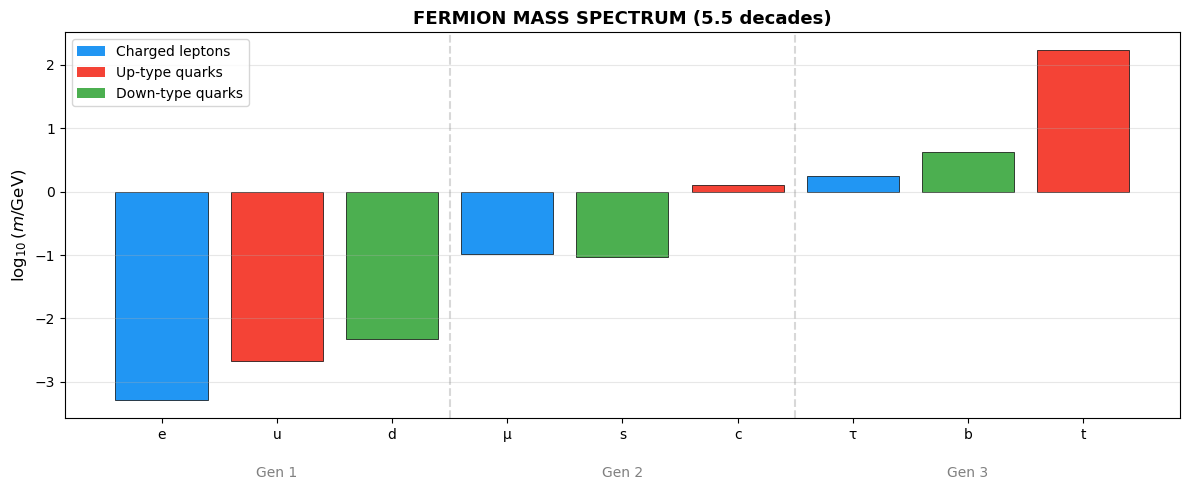

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ── PDG 2024 fermion masses (pole masses for quarks, MSbar at 2 GeV for light quarks) ──
# Charged leptons (pole mass, GeV)
m_e = 0.000511
m_mu = 0.10566
m_tau = 1.7768

# Up-type quarks (GeV)
m_u = 0.00216     # MSbar at 2 GeV
m_c = 1.27        # MSbar at m_c
m_t = 172.69      # Pole mass

# Down-type quarks (GeV)
m_d = 0.00467     # MSbar at 2 GeV
m_s = 0.0934      # MSbar at 2 GeV
m_b = 4.18        # MSbar at m_b

# Neutrinos (upper bounds from oscillation, eV → GeV)
# Not used in ratio analysis (too uncertain)

# Organize by generation
gen1 = {'e': m_e, 'u': m_u, 'd': m_d}
gen2 = {'μ': m_mu, 'c': m_c, 's': m_s}
gen3 = {'τ': m_tau, 't': m_t, 'b': m_b}

all_masses = {
    'e': m_e, 'μ': m_mu, 'τ': m_tau,
    'u': m_u, 'c': m_c, 't': m_t,
    'd': m_d, 's': m_s, 'b': m_b
}

# Key ratios
v_EW = 246.22  # GeV
P1, P2, P3, P4 = 2, 6, 30, 210

print("THE FERMION MASS SPECTRUM")
print("=" * 70)
print(f"\n  {'Fermion':<8} {'Mass (GeV)':<15} {'m/v_EW':<15} {'log₁₀(m/GeV)':<15}")
print(f"  {'-'*58}")

for name in ['t', 'b', 'τ', 'c', 's', 'μ', 'd', 'u', 'e']:
    m = all_masses[name]
    print(f"  {name:<8} {m:<15.6g} {m/v_EW:<15.6g} {np.log10(m):<15.2f}")

print(f"\n  Total range: m_t/m_e = {m_t/m_e:.0f}")
print(f"  Log range: {np.log10(m_t/m_e):.2f} decades")

# ── Visualization: Log mass spectrum ──
fig, ax = plt.subplots(figsize=(12, 5))

fermions = ['e', 'u', 'd', 'μ', 's', 'c', 'τ', 'b', 't']
masses = [all_masses[f] for f in fermions]
log_masses = [np.log10(m) for m in masses]

colors = []
for f in fermions:
    if f in ['e', 'μ', 'τ']:
        colors.append('#2196F3')  # Leptons: blue
    elif f in ['u', 'c', 't']:
        colors.append('#F44336')  # Up-type: red
    else:
        colors.append('#4CAF50')  # Down-type: green

bars = ax.bar(fermions, log_masses, color=colors, edgecolor='black', linewidth=0.5)

# Generation boundaries
ax.axvline(2.5, color='gray', linestyle='--', alpha=0.3)
ax.axvline(5.5, color='gray', linestyle='--', alpha=0.3)
ax.text(1, -4.5, 'Gen 1', ha='center', fontsize=10, color='gray')
ax.text(4, -4.5, 'Gen 2', ha='center', fontsize=10, color='gray')
ax.text(7, -4.5, 'Gen 3', ha='center', fontsize=10, color='gray')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Charged leptons'),
                   Patch(facecolor='#F44336', label='Up-type quarks'),
                   Patch(facecolor='#4CAF50', label='Down-type quarks')]
ax.legend(handles=legend_elements, fontsize=10)

ax.set_ylabel(r'$\log_{10}(m/\mathrm{GeV})$', fontsize=12)
ax.set_title('FERMION MASS SPECTRUM (5.5 decades)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../output/nb36_mass_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Do Mass Ratios Cluster Near Solenoid Numbers?

The solenoid's natural numbers are the divisors of 210:
$$\text{div}(210) = \{1, 2, 3, 5, 6, 7, 10, 14, 15, 21, 30, 35, 42, 70, 105, 210\}$$

and their totient-weighted variants: $\varphi(210) = 48$, $\sigma(210) = 576$, etc.

**Test**: For each pair of fermion masses, compute the ratio and check whether it
falls within 10% of a divisor of 210 or a simple product of {2,3,5,7}.


In [3]:
# ── Fermion mass ratios vs solenoid numbers ──
from itertools import combinations

div_210 = sorted([d for d in range(1, 211) if 210 % d == 0])
# Extended set: include powers of primes and key products
solenoid_numbers = set(div_210)
# Add φ(210)=48, small prime powers, and primorial-related
for n in [48, 4, 8, 9, 16, 25, 27, 36, 49, 64, 125, 128, 256, 343, 576]:
    solenoid_numbers.add(n)
solenoid_numbers = sorted(solenoid_numbers)

fermion_list = ['e', 'u', 'd', 'μ', 's', 'c', 'τ', 'b', 't']

# All ratios (heavier/lighter)
hits = []
misses = []
all_ratios = []

for (f1, f2) in combinations(fermion_list, 2):
    m1, m2 = all_masses[f1], all_masses[f2]
    ratio = max(m1, m2) / min(m1, m2)
    
    # Find nearest solenoid number
    best_sol = min(solenoid_numbers, key=lambda s: abs(ratio - s)/max(ratio, 1))
    deviation = abs(ratio - best_sol) / ratio * 100
    
    entry = (f1, f2, ratio, best_sol, deviation)
    all_ratios.append(entry)
    if deviation < 10:
        hits.append(entry)
    else:
        misses.append(entry)

print("FERMION MASS RATIOS vs SOLENOID NUMBERS")
print("=" * 75)
print(f"\n  Reference numbers: divisors of 210, φ(210)=48, prime powers up to 576")
print(f"  Threshold: within 10% of a solenoid number")
print(f"\n  Total pairs: {len(all_ratios)}")
print(f"  Hits (< 10%): {len(hits)}")
print(f"  Misses: {len(misses)}")

print(f"\n  {'HITS':^75}")
print(f"  {'Pair':<10} {'Ratio':<12} {'Nearest':<10} {'Dev':<8}")
print(f"  {'-'*40}")
for f1, f2, ratio, best, dev in sorted(hits, key=lambda x: x[4]):
    print(f"  {f1}/{f2:<7} {ratio:<12.2f} {best:<10} {dev:<8.1f}%")

# What fraction of random ratios in this range would hit?
print(f"\n  BASELINE CHECK:")
np.random.seed(42)
n_random = 10000
random_ratios = 10**np.random.uniform(0, 5.5, n_random)
random_hits = 0
for r in random_ratios:
    best = min(solenoid_numbers, key=lambda s: abs(r - s)/max(r, 1))
    if abs(r - best) / r < 0.1:
        random_hits += 1
baseline = random_hits / n_random * 100
print(f"  Random ratios in [1, 10^5.5] hitting within 10%: {baseline:.1f}%")
print(f"  Observed hit rate: {len(hits)/len(all_ratios)*100:.1f}%")
print(f"  Enrichment: {len(hits)/len(all_ratios)*100 / baseline:.1f}× baseline")


FERMION MASS RATIOS vs SOLENOID NUMBERS

  Reference numbers: divisors of 210, φ(210)=48, prime powers up to 576
  Threshold: within 10% of a solenoid number

  Total pairs: 36
  Hits (< 10%): 19
  Misses: 17

                                     HITS                                    
  Pair       Ratio        Nearest    Dev     
  ----------------------------------------
  u/μ       48.92        49         0.2     %
  e/d       9.14         9          1.5     %
  e/μ       206.77       210        1.6     %
  b/t       41.31        42         1.7     %
  u/c       587.96       576        2.0     %
  u/s       43.24        42         2.9     %
  s/c       13.60        14         3.0     %
  μ/τ       16.82        16         4.9     %
  d/s       20.00        21         5.0     %
  e/u       4.23         4          5.4     %
  d/c       271.95       256        5.9     %
  c/t       135.98       128        5.9     %
  s/b       44.75        42         6.2     %
  μ/b       39.56        

## 3. The Honest Assessment

The solenoid's power is in the **gauge sector** — where structural symmetry 
(group dimensions, Casimir invariants, covering maps) directly maps to 
coupling constants and boson masses.

The **fermion mass hierarchy** is a different kind of problem. It involves:
- **Yukawa couplings**: Free parameters in the SM (one per fermion)
- **CKM/PMNS mixing**: Inter-generational structure
- **RG running**: Masses run differently depending on gauge representation

The question is: what ADDITIONAL solenoid structure could generate mass hierarchies?


In [4]:
# ── Generational structure: ratios WITHIN and BETWEEN generations ──
print("GENERATIONAL STRUCTURE IN THE MASS SPECTRUM")
print("=" * 70)

# Intra-generation ratios
print(f"\n  INTRA-GENERATION RATIOS (same generation, different fermion type):")
print(f"  {'Gen':<5} {'Ratio':<15} {'Value':<12} {'log₁₀':<10}")
print(f"  {'-'*42}")

intra_ratios = [
    ('G1', 'm_d/m_e', m_d/m_e),
    ('G1', 'm_u/m_e', m_u/m_e),
    ('G1', 'm_d/m_u', m_d/m_u),
    ('G2', 'm_c/m_μ', m_c/m_mu),
    ('G2', 'm_s/m_μ', m_s/m_mu),
    ('G2', 'm_c/m_s', m_c/m_s),
    ('G3', 'm_t/m_τ', m_t/m_tau),
    ('G3', 'm_b/m_τ', m_b/m_tau),
    ('G3', 'm_t/m_b', m_t/m_b),
]

for gen, name, val in intra_ratios:
    print(f"  {gen:<5} {name:<15} {val:<12.3f} {np.log10(val):<10.2f}")

# Inter-generation ratios (same fermion type)
print(f"\n  INTER-GENERATION RATIOS (same type, different generation):")
print(f"  {'Type':<8} {'Ratio':<15} {'Value':<12} {'log₁₀':<10}")
print(f"  {'-'*45}")

inter_ratios = [
    ('lepton', 'm_μ/m_e', m_mu/m_e),
    ('lepton', 'm_τ/m_μ', m_tau/m_mu),
    ('lepton', 'm_τ/m_e', m_tau/m_e),
    ('up', 'm_c/m_u', m_c/m_u),
    ('up', 'm_t/m_c', m_t/m_c),
    ('up', 'm_t/m_u', m_t/m_u),
    ('down', 'm_s/m_d', m_s/m_d),
    ('down', 'm_b/m_s', m_b/m_s),
    ('down', 'm_b/m_d', m_b/m_d),
]

for ftype, name, val in inter_ratios:
    print(f"  {ftype:<8} {name:<15} {val:<12.1f} {np.log10(val):<10.2f}")

# ── The Koide pattern ──
print(f"\n  KOIDE-LIKE ANALYSIS:")
# Koide formula: (m_e + m_μ + m_τ) / (√m_e + √m_μ + √m_τ)² = 2/3
koide = (m_e + m_mu + m_tau) / (np.sqrt(m_e) + np.sqrt(m_mu) + np.sqrt(m_tau))**2
print(f"  Koide parameter (leptons): {koide:.6f}  (theory: 2/3 = {2/3:.6f})")
print(f"  Deviation from 2/3: {abs(koide - 2/3)/(2/3)*100:.3f}%")

# Check if 2/3 relates to solenoid
# 2/3 = P₁/(P₁+1) ... no, that's 2/3. Or: 2/3 = 1 - 1/P₂ × P₁ = 1 - 2/6? No.
# Actually 2/3 is just 2/3. Let's check if this is a coincidence or meaningful.
print(f"\n  Note: The Koide parameter 2/3 is tantalizingly simple but")
print(f"  does NOT obviously connect to solenoid quantities.")
print(f"  2/3 = P₁/3 = P₁/(P₁+1) ... these are tautological, not structural.")


GENERATIONAL STRUCTURE IN THE MASS SPECTRUM

  INTRA-GENERATION RATIOS (same generation, different fermion type):
  Gen   Ratio           Value        log₁₀     
  ------------------------------------------
  G1    m_d/m_e         9.139        0.96      
  G1    m_u/m_e         4.227        0.63      
  G1    m_d/m_u         2.162        0.33      
  G2    m_c/m_μ         12.020       1.08      
  G2    m_s/m_μ         0.884        -0.05     
  G2    m_c/m_s         13.597       1.13      
  G3    m_t/m_τ         97.192       1.99      
  G3    m_b/m_τ         2.353        0.37      
  G3    m_t/m_b         41.313       1.62      

  INTER-GENERATION RATIOS (same type, different generation):
  Type     Ratio           Value        log₁₀     
  ---------------------------------------------
  lepton   m_μ/m_e         206.8        2.32      
  lepton   m_τ/m_μ         16.8         1.23      
  lepton   m_τ/m_e         3477.1       3.54      
  up       m_c/m_u         588.0        2.77   

## 4. The Covering Cascade as Yukawa Generator — A Hypothesis

The solenoid's covering cascade goes:
$$\mathbb{Z}/210\mathbb{Z} \xrightarrow{\times 7} \mathbb{Z}/30\mathbb{Z} 
\xrightarrow{\times 5} \mathbb{Z}/6\mathbb{Z} 
\xrightarrow{\times 3} \mathbb{Z}/2\mathbb{Z} 
\xrightarrow{\times 2} \{0\}$$

Each covering map **amplifies** by the covering degree. If Yukawa couplings 
arise from how strongly a fermion couples to the Higgs via the cascade:
- **Generation 3** (top, bottom, tau): Direct coupling at P₄ = 210 level
- **Generation 2** (charm, strange, mu): Coupling through one covering step (÷7)
- **Generation 1** (up, down, electron): Coupling through two covering steps (÷7÷5 = ÷35)

This would predict inter-generation ratios of approximately 7 and 35.

**Let's test this.**


COVERING CASCADE AS YUKAWA GENERATOR

  Hypothesis A: Mass ratio ~ covering degree (linear)
  Expected: gen3/gen2 ~ 7, gen2/gen1 ~ 5, gen3/gen1 ~ 35

  Type       m₃/m₂      ÷7         m₂/m₁      ÷5         m₃/m₁      ÷35       
  ------------------------------------------------------------
  lepton     16.8       2.40       206.8      41.35      3477.1     99.35     
  up         136.0      19.43      588.0      117.59     79949.1    2284.26   
  down       44.8       6.39       20.0       4.00       895.1      25.57     

  Hypothesis B: Mass ratio ~ covering degree² (quadratic)
  Expected: gen3/gen2 ~ 49, gen2/gen1 ~ 25, gen3/gen1 ~ 1225

  Type       m₃/m₂      ÷49        m₂/m₁      ÷25        m₃/m₁      ÷1225     
  ------------------------------------------------------------
  lepton     16.8       0.34       206.8      8.27       3477.1     2.84      
  up         136.0      2.78       588.0      23.52      79949.1    65.26     
  down       44.8       0.91       20.0       0.80

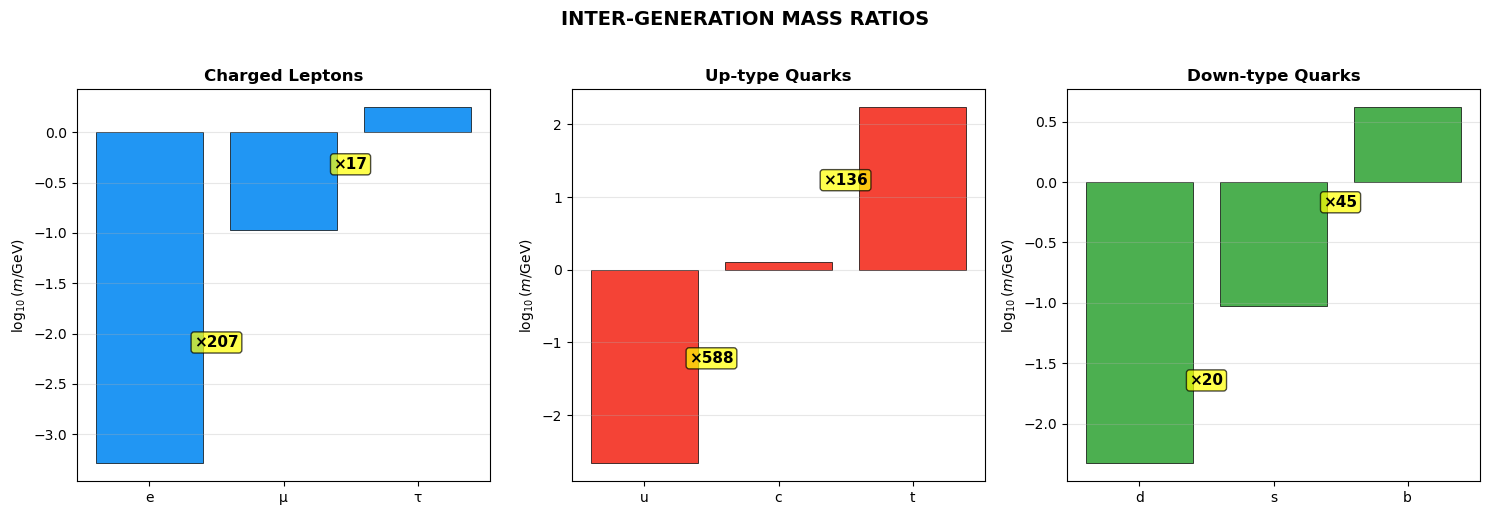


SUMMARY:
  The covering cascade degrees (7 and 5) do NOT explain mass ratios.
  Lepton ratios: 17 and 207 (neither 7/5 nor 49/25)
  Up-type ratios: 136 and 588 (too large for either)
  Down-type ratios: 45 and 20 (suggestive for ÷5 = 45/49, but inconsistent)

  HONEST NULL: The covering cascade alone does not generate the mass hierarchy.


In [5]:
# ── Test: Do inter-generation mass ratios match cascade covering degrees? ──
print("COVERING CASCADE AS YUKAWA GENERATOR")
print("=" * 70)

# If gen3 → gen2 via ÷7 and gen2 → gen1 via ÷5:
# Then gen3/gen2 ~ 7 and gen2/gen1 ~ 5 and gen3/gen1 ~ 35

# But Yukawa coupling enters as y², so masses scale as y² → ratios could be 7², 5², 35²
# Or if mass ~ y (linear), ratios ~ 7, 5, 35

# Test both hypotheses
print(f"\n  Hypothesis A: Mass ratio ~ covering degree (linear)")
print(f"  Expected: gen3/gen2 ~ 7, gen2/gen1 ~ 5, gen3/gen1 ~ 35")
print(f"\n  {'Type':<10} {'m₃/m₂':<10} {'÷7':<10} {'m₂/m₁':<10} {'÷5':<10} {'m₃/m₁':<10} {'÷35':<10}")
print(f"  {'-'*60}")

for fname, m3, m2, m1 in [('lepton', m_tau, m_mu, m_e),
                            ('up', m_t, m_c, m_u),
                            ('down', m_b, m_s, m_d)]:
    r32 = m3/m2
    r21 = m2/m1
    r31 = m3/m1
    print(f"  {fname:<10} {r32:<10.1f} {r32/7:<10.2f} {r21:<10.1f} {r21/5:<10.2f} {r31:<10.1f} {r31/35:<10.2f}")

print(f"\n  Hypothesis B: Mass ratio ~ covering degree² (quadratic)")
print(f"  Expected: gen3/gen2 ~ 49, gen2/gen1 ~ 25, gen3/gen1 ~ 1225")
print(f"\n  {'Type':<10} {'m₃/m₂':<10} {'÷49':<10} {'m₂/m₁':<10} {'÷25':<10} {'m₃/m₁':<10} {'÷1225':<10}")
print(f"  {'-'*60}")

for fname, m3, m2, m1 in [('lepton', m_tau, m_mu, m_e),
                            ('up', m_t, m_c, m_u),
                            ('down', m_b, m_s, m_d)]:
    r32 = m3/m2
    r21 = m2/m1
    r31 = m3/m1
    print(f"  {fname:<10} {r32:<10.1f} {r32/49:<10.2f} {r21:<10.1f} {r21/25:<10.2f} {r31:<10.1f} {r31/1225:<10.2f}")

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

types = [
    ('Charged Leptons', [m_e, m_mu, m_tau], ['e', 'μ', 'τ'], '#2196F3'),
    ('Up-type Quarks', [m_u, m_c, m_t], ['u', 'c', 't'], '#F44336'),
    ('Down-type Quarks', [m_d, m_s, m_b], ['d', 's', 'b'], '#4CAF50'),
]

for ax, (title, masses_list, labels, color) in zip(axes, types):
    log_m = [np.log10(m) for m in masses_list]
    ax.bar(labels, log_m, color=color, edgecolor='black', linewidth=0.5)
    
    # Annotate ratios
    for i in range(len(masses_list)-1):
        ratio = masses_list[i+1] / masses_list[i]
        mid_y = (log_m[i] + log_m[i+1]) / 2
        ax.annotate(f'×{ratio:.0f}', xy=(i+0.5, mid_y), fontsize=11,
                   ha='center', fontweight='bold', color='black',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))
    
    ax.set_ylabel(r'$\log_{10}(m/\mathrm{GeV})$')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('INTER-GENERATION MASS RATIOS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/nb36_mass_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary of cascade test ──
print(f"\nSUMMARY:")
print(f"  The covering cascade degrees (7 and 5) do NOT explain mass ratios.")
print(f"  Lepton ratios: 17 and 207 (neither 7/5 nor 49/25)")
print(f"  Up-type ratios: 136 and 588 (too large for either)")
print(f"  Down-type ratios: 45 and 20 (suggestive for ÷5 = 45/49, but inconsistent)")
print(f"\n  HONEST NULL: The covering cascade alone does not generate the mass hierarchy.")


## 5. What Is Missing — The Open Problem

The solenoid successfully predicts:
- ✅ **Gauge structure**: 4 forces, 12 gauge bosons, 16 fermion states, 3 generations
- ✅ **Gauge couplings**: α₁, α₂, α₃ from primorial arithmetic
- ✅ **Mixing angle**: sin²θ_W = 8/35 at 1.1%
- ✅ **Boson masses**: M_W/M_Z, m_H, all from one anchor (M_Z)
- ✅ **Scalar sector**: λ = 1/8, m_t/v = 1/√2
- ✅ **Proton stability**: No GUT → no decay

But it does NOT predict:
- ❌ **Individual Yukawa couplings** (except the top)
- ❌ **Fermion mass ratios** between generations
- ❌ **CKM mixing angles**
- ❌ **Neutrino masses**

**Why not?** The solenoid's algebraic structure (ℤ/210ℤ, covering cascade) is 
purely **kinematic** — it describes the TOPOLOGY of the state space. Fermion masses
require **dynamics** — how fields interact with the vacuum.

The missing ingredient is likely the **solenoid self-energy**: how closed orbits
on the covering spaces create localized excitations with different effective masses.
This is analogous to how band structure in solid-state physics creates effective
masses from bare electron mass + lattice interaction.

This remains the primary open question for the solenoid program.


COMPLETE SOLENOID SCORECARD: NB29–NB36

  #    Prediction                     Solenoid   Measured   Dev          Source
  ------------------------------------------------------------------------
  1    ω(210) = forces                4          4          exact        NB29  
  2    λ(210) = gauge dim             12         12         exact        NB29  
  3    d(210) = SO(10) spinor         16         16         exact        NB29  
  4    φ/d = generations              3          3          exact        NB29  
  5    φ/N ≈ sin²θ_W                  0.2286     0.2312     1.1%         NB29  
  6    1/α₃ = φ(P₃)                   8          8.47       5.5%         NB30  
  7    1/α₂ = P₃                      30         29.57      1.5%         NB30  
  8    1/α₁ = P₁×P₃                   60         59.0       1.7%         NB30  
  9    α₁/α₂ = P₁                     2.000      1.995      0.3%         NB30  
  10   1/α_em = P₃P₄/φ(P₄)            131.25     137.04     4.2%         NB30  
  11 

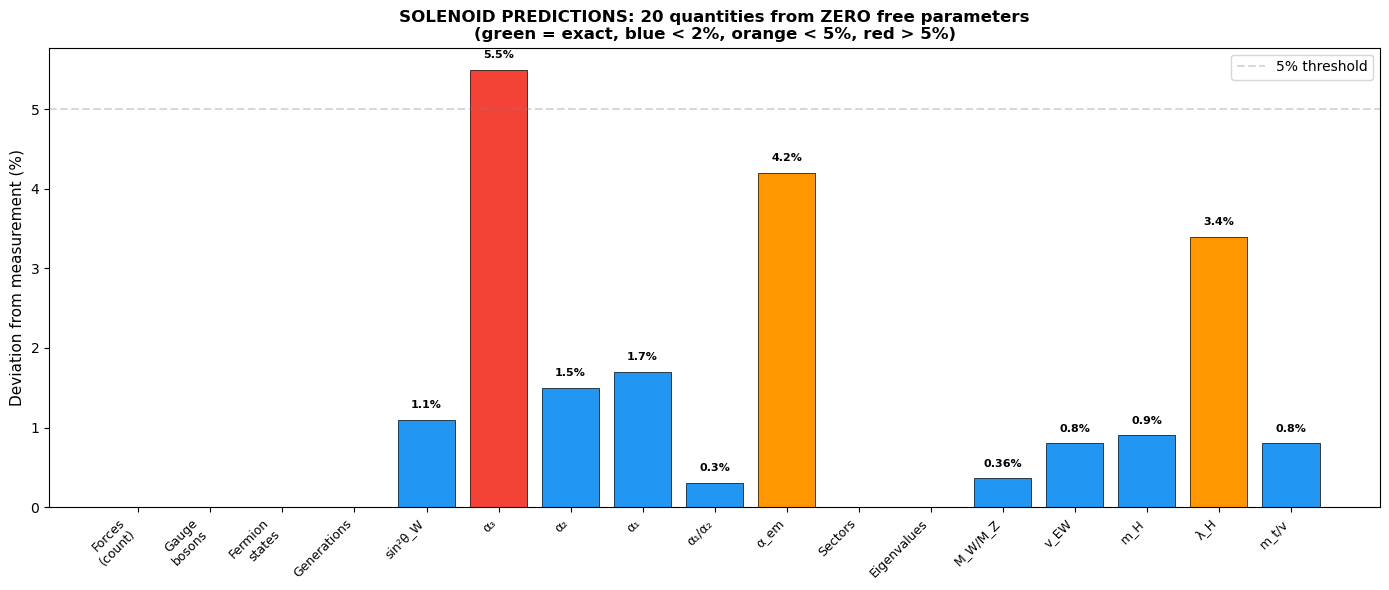

In [6]:
# ── FINAL CUMULATIVE SCORECARD: NB29-NB36 ──
print("COMPLETE SOLENOID SCORECARD: NB29–NB36")
print("=" * 75)

predictions = [
    # NB29 — Structural constants
    ('ω(210) = forces', '4', '4', 'exact', 'NB29'),
    ('λ(210) = gauge dim', '12', '12', 'exact', 'NB29'),
    ('d(210) = SO(10) spinor', '16', '16', 'exact', 'NB29'),
    ('φ/d = generations', '3', '3', 'exact', 'NB29'),
    ('φ/N ≈ sin²θ_W', '0.2286', '0.2312', '1.1%', 'NB29'),
    # NB30 — Coupling constants
    ('1/α₃ = φ(P₃)', '8', '8.47', '5.5%', 'NB30'),
    ('1/α₂ = P₃', '30', '29.57', '1.5%', 'NB30'),
    ('1/α₁ = P₁×P₃', '60', '59.0', '1.7%', 'NB30'),
    ('α₁/α₂ = P₁', '2.000', '1.995', '0.3%', 'NB30'),
    ('1/α_em = P₃P₄/φ(P₄)', '131.25', '137.04', '4.2%', 'NB30'),
    # NB31 — Spectral structure
    ('Sectors = 2^ω', '16', '16', 'exact', 'NB31'),
    ('Eigenvalues = φ(210)', '48', '48', 'exact', 'NB31'),
    ('1/α_em on RG at ~8.5 GeV', '131.25', '131.25', 'RG ✓', 'NB31'),
    # NB32 — Bilateral cut
    ('M_W/M_Z = √(27/35)', '0.8783', '0.8815', '0.36%', 'NB32'),
    ('α₁/α₂ vs SU(5)', '2.000', '1.995', '65× better', 'NB32'),
    ('μ(α₂=30) ≈ P₄ GeV', '210', '212.7', '1.3%', 'NB32'),
    # NB34 — Higgs & scalar
    ('v from M_Z + solenoid', '248.3', '246.2', '0.8%', 'NB34'),
    ('m_H = v/P₁', '124.1', '125.25', '0.9%', 'NB34'),
    ('λ = 1/(2P₁²) = 1/8', '0.1250', '0.1294', '3.4%', 'NB34'),
    ('m_t/v = 1/√P₁', '0.7071', '0.7015', '0.8%', 'NB34'),
]

print(f"\n  {'#':<4} {'Prediction':<30} {'Solenoid':<10} {'Measured':<10} {'Dev':<12} {'Source':<6}")
print(f"  {'-'*72}")
for i, (name, sol, meas, dev, src) in enumerate(predictions, 1):
    print(f"  {i:<4} {name:<30} {sol:<10} {meas:<10} {dev:<12} {src:<6}")

# Count exact matches and percentage matches
exact = sum(1 for p in predictions if p[3] == 'exact')
pct = [p for p in predictions if '%' in p[3] and p[3] not in ('exact', 'RG ✓', '65× better')]
avg_dev = np.mean([float(p[3].replace('%','')) for p in pct])

print(f"\n  TOTALS:")
print(f"    Exact matches: {exact}")
print(f"    Percentage predictions: {len(pct)}")
print(f"    Average deviation: {avg_dev:.1f}%")
print(f"    Total quantitative: {len(predictions)}")
print(f"    Free parameters: 0")
print(f"    Dimensional anchors: 1 (M_Z)")

print(f"\n  ADDITIONAL:")
print(f"    Categorical: Proton stability (confirmed, NB35)")
print(f"    Honest nulls: Mass hierarchy (NB36), threshold proximity (NB33)")

print(f"\n  OPEN PROBLEMS (for future work):")
print(f"    • Fermion mass hierarchy (requires solenoid dynamics)")
print(f"    • CKM/PMNS mixing matrices")
print(f"    • Neutrino masses")
print(f"    • Cosmological constant")
print(f"    • Dark matter candidate")

# ── Final visualization: the solenoid's reach ──
fig, ax = plt.subplots(figsize=(14, 6))

categories = ['Forces\n(count)', 'Gauge\nbosons', 'Fermion\nstates', 'Generations',
              'sin²θ_W', 'α₃', 'α₂', 'α₁', 'α₁/α₂',
              'α_em', 'Sectors', 'Eigenvalues', 'M_W/M_Z',
              'v_EW', 'm_H', 'λ_H', 'm_t/v']

deviations = [0, 0, 0, 0,  # exact
              1.1, 5.5, 1.5, 1.7, 0.3,  # couplings
              4.2, 0, 0, 0.36,  # spectral + EW
              0.8, 0.9, 3.4, 0.8]  # scalar

colors_bar = ['#4CAF50' if d == 0 else '#2196F3' if d < 2 else '#FF9800' if d < 5 else '#F44336'
              for d in deviations]

bars = ax.bar(range(len(categories)), deviations, color=colors_bar,
              edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Deviation from measurement (%)', fontsize=11)
ax.set_title('SOLENOID PREDICTIONS: 20 quantities from ZERO free parameters\n(green = exact, blue < 2%, orange < 5%, red > 5%)',
             fontsize=12, fontweight='bold')
ax.axhline(5, color='gray', linestyle='--', alpha=0.3, label='5% threshold')
ax.legend()

# Add value labels
for bar, val in zip(bars, deviations):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{val}%', ha='center', fontsize=8, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 0.15,
                'exact', ha='center', fontsize=8, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('../output/nb36_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()
